# Traffic Analyzer — Data Analysis

This notebook loads the raw `data/traffic_data.csv` produced by the Traffic Analyzer,
performs aggregations, and generates charts for the project submission.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
# ── Load and Inspect the CSV Data ─────────────────────────────────────────────
df = pd.read_csv("data/traffic_data.csv")

print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}\n")
df.head(10)


Rows: 690
Columns: ['timestamp', 'frame_number', 'bicycle', 'car', 'motorcycle', 'bus', 'truck', 'total_vehicles', 'density_level', 'rolling_avg_5', 'hour_of_day', 'day_of_week', 'events']



,timestamp,frame_number,bicycle,car,motorcycle,bus,truck,total_vehicles,density_level,rolling_avg_5,hour_of_day,day_of_week,events
0,2026-04-08T16:01:26.058367,30,0,6,0,0,1,7,medium,7.00,16,Wednesday,RUSH_HOUR_START|SESSION_PEAK
1,2026-04-08T16:01:26.785089,60,0,5,0,0,2,7,medium,7.00,16,Wednesday,NaN
2,2026-04-08T16:01:27.269987,90,0,4,0,0,1,5,medium,6.33,16,Wednesday,NaN
3,2026-04-08T16:01:28.309475,120,0,3,0,0,1,4,medium,5.75,16,Wednesday,NaN
4,2026-04-08T16:01:28.793277,150,0,2,0,0,1,3,medium,5.20,16,Wednesday,HEAVY_VEHICLE_PEAK|SUSTAINED_FLOW
5,2026-04-08T16:01:29.536638,180,0,2,0,0,1,3,medium,4.40,16,Wednesday,HEAVY_VEHICLE_PEAK|SUSTAINED_FLOW
6,2026-04-08T16:01:29.994503,210,0,1,0,0,1,2,low,3.40,16,Wednesday,HEAVY_VEHICLE_PEAK|QUIET_PERIOD
7,2026-04-08T16:01:30.870400,240,0,1,0,0,1,2,low,2.80,16,Wednesday,HEAVY_VEHICLE_PEAK|QUIET_PERIOD|DEAD_ZONE
8,2026-04-08T16:01:31.344137,270,0,2,0,0,1,3,medium,2.60,16,Wednesday,HEAVY_VEHICLE_PEAK
9,2026-04-08T16:01:32.058739,300,0,2,0,0,0,2,low,2.40,16,Wednesday,QUIET_PERIOD


In [3]:
df.describe()


,frame_number,bicycle,car,motorcycle,bus,truck,total_vehicles,rolling_avg_5,hour_of_day
count,690.000000,690.0,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,3089.173913,0.0,3.276812,0.005797,0.110145,0.181159,3.573913,3.555333,11.431884
std,2230.303184,0.0,2.906409,0.075973,0.380262,0.511628,3.221555,3.019977,2.166274
min,30.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,1147.500000,0.0,1.000000,0.000000,0.000000,0.000000,1.000000,1.400000,10.000000
50%,2610.000000,0.0,3.000000,0.000000,0.000000,0.000000,3.000000,2.800000,11.000000
75%,4972.500000,0.0,5.000000,0.000000,0.000000,0.000000,5.000000,4.800000,11.000000
max,7680.000000,0.0,15.000000,1.000000,3.000000,3.000000,16.000000,13.600000,16.000000


In [4]:
# ── Data Cleaning and Preprocessing ───────────────────────────────────────────
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.dropna(subset=["timestamp", "total_vehicles"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Fill empty events column with empty string
df["events"] = df["events"].fillna("")

print(f"Date range: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Total samples: {len(df)}")
print(f"Average vehicles per sample: {df['total_vehicles'].mean():.2f}")


Date range: 2026-04-08 16:01:26.058367  →  2026-04-14 11:08:25.364109
Total samples: 690
Average vehicles per sample: 3.57


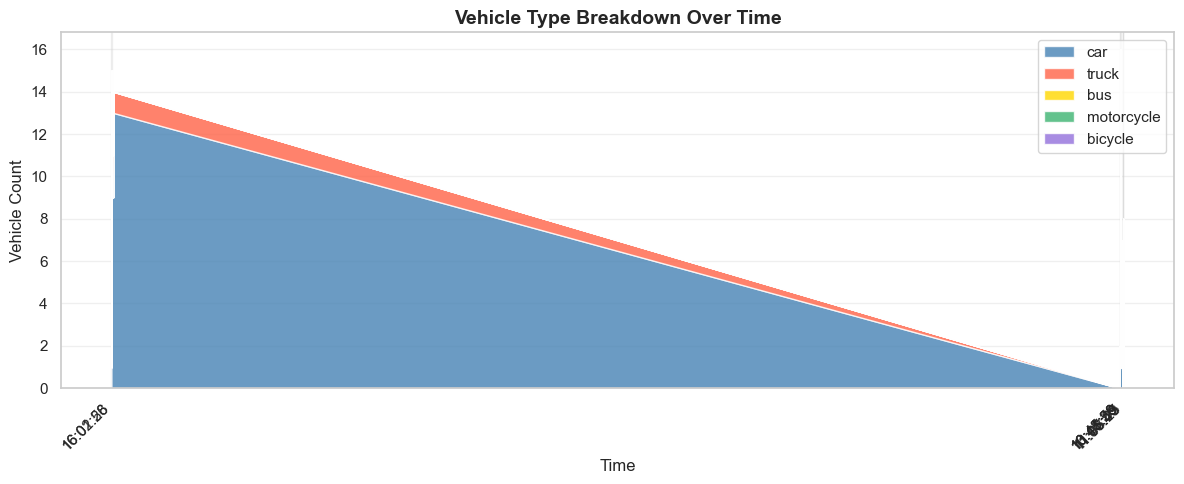

Saved → data/chart_vehicle_types.png


In [6]:
# ── Chart 2: Vehicle Type Breakdown (Stacked Area) ────────────────────────────
vehicle_types = ["car", "truck", "bus", "motorcycle", "bicycle"]
colors = ["steelblue", "tomato", "gold", "mediumseagreen", "mediumpurple"]

fig, ax = plt.subplots()
ax.stackplot(df["elapsed_s"],
             [df[v] for v in vehicle_types],
             labels=vehicle_types, colors=colors, alpha=0.8)

n_ticks = min(8, len(df))
tick_idx = [int(i * (len(df) - 1) / (n_ticks - 1)) for i in range(n_ticks)]
ax.set_xticks([df["elapsed_s"].iloc[i] for i in tick_idx])
ax.set_xticklabels([df["timestamp"].iloc[i].strftime("%H:%M:%S") for i in tick_idx], rotation=45, ha="right")

ax.set_title("Vehicle Type Breakdown Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Vehicle Count")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/chart_vehicle_types.png", dpi=150)
plt.show()
print("Saved → data/chart_vehicle_types.png")


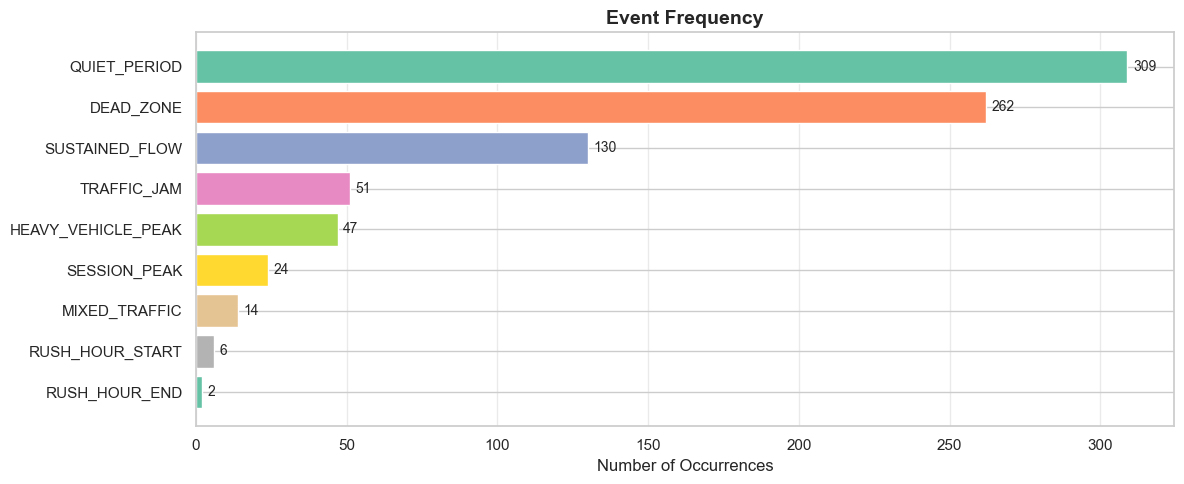

Saved → data/chart_event_frequency.png

Event counts:
             Event  Count
      QUIET_PERIOD    309
         DEAD_ZONE    262
    SUSTAINED_FLOW    130
       TRAFFIC_JAM     51
HEAVY_VEHICLE_PEAK     47
      SESSION_PEAK     24
     MIXED_TRAFFIC     14
   RUSH_HOUR_START      6
     RUSH_HOUR_END      2


In [7]:
# ── Chart 3: Event Frequency Bar Chart ────────────────────────────────────────
# Flatten the pipe-separated events column into individual event names
all_events = []
for cell in df["events"]:
    if cell:
        all_events.extend(cell.split("|"))

event_counts = Counter(all_events)
event_df = pd.DataFrame(event_counts.items(), columns=["Event", "Count"])
event_df = event_df.sort_values("Count", ascending=False)

fig, ax = plt.subplots()
bars = ax.barh(event_df["Event"], event_df["Count"],
               color=sns.color_palette("Set2", len(event_df)))

ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title("Event Frequency", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Occurrences")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig("data/chart_event_frequency.png", dpi=150)
plt.show()
print("Saved → data/chart_event_frequency.png")
print("\nEvent counts:")
print(event_df.to_string(index=False))


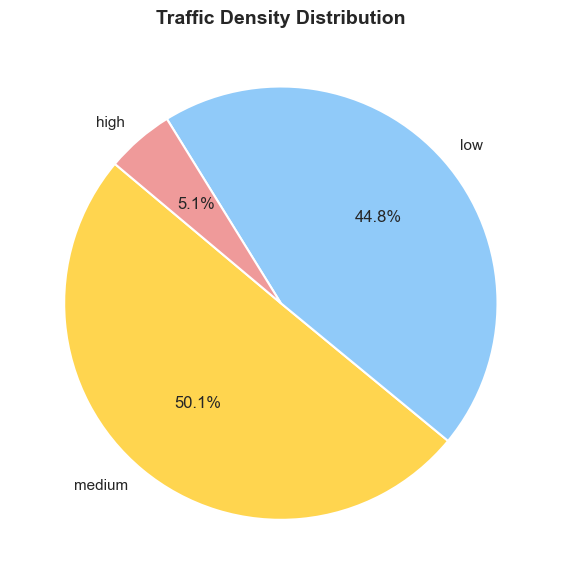

Saved → data/chart_density_distribution.png


In [8]:
# ── Chart 4: Density Level Distribution (Pie Chart) ───────────────────────────
density_counts = df["density_level"].value_counts()
colors_pie = {"low": "#90CAF9", "medium": "#FFD54F", "high": "#EF9A9A"}

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(density_counts,
       labels=density_counts.index,
       autopct="%1.1f%%",
       colors=[colors_pie.get(l, "grey") for l in density_counts.index],
       startangle=140,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})

ax.set_title("Traffic Density Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("data/chart_density_distribution.png", dpi=150)
plt.show()
print("Saved → data/chart_density_distribution.png")


In [9]:
# ── Key Statistics Summary ─────────────────────────────────────────────────────
total_samples  = len(df)
session_start  = df["timestamp"].min().strftime("%Y-%m-%d %H:%M:%S")
session_end    = df["timestamp"].max().strftime("%Y-%m-%d %H:%M:%S")
peak_vehicles  = df["total_vehicles"].max()
avg_vehicles   = df["total_vehicles"].mean()
pct_low        = (df["density_level"] == "low").mean() * 100
pct_medium     = (df["density_level"] == "medium").mean() * 100
pct_high       = (df["density_level"] == "high").mean() * 100
top_event      = event_df.iloc[0]["Event"] if not event_df.empty else "N/A"
total_events   = sum(event_counts.values())

print("=" * 50)
print("  TRAFFIC ANALYZER — SESSION SUMMARY")
print("=" * 50)
print(f"  Session start   : {session_start}")
print(f"  Session end     : {session_end}")
print(f"  Total samples   : {total_samples}")
print(f"  Peak vehicles   : {peak_vehicles}")
print(f"  Average vehicles: {avg_vehicles:.2f}")
print(f"  Density — low   : {pct_low:.1f}%")
print(f"  Density — medium: {pct_medium:.1f}%")
print(f"  Density — high  : {pct_high:.1f}%")
print(f"  Total events    : {total_events}")
print(f"  Most common evt : {top_event}")
print("=" * 50)


  TRAFFIC ANALYZER — SESSION SUMMARY
  Session start   : 2026-04-08 16:01:26
  Session end     : 2026-04-14 11:08:25
  Total samples   : 690
  Peak vehicles   : 16
  Average vehicles: 3.57
  Density — low   : 44.8%
  Density — medium: 50.1%
  Density — high  : 5.1%
  Total events    : 845
  Most common evt : QUIET_PERIOD
